# Static CNN Baseline

I keep this notebook as the baseline from my earlier hand-gesture image classification work. The current repo moves beyond this static-image setup toward video-based ASL recognition with hand landmarks and temporal modeling.

This notebook is included for context and comparison only; the main app direction is implemented in the `src/` and `app/` folders.


In [1]:
#https:// https://colab.research.google.com/drive/1l80mnIXLSYabKasijiaZcnyNEvZf_2T9?usp=sharing

In [2]:
#Download the anonymized data provided on Quercus (A2_Hand_Gesture_Dataset_Revised.zip).
#Split the data into training, validation, and test sets. Do not use A2_Hand_Gesture_Unlabeled_Data.zip
#which will be used in later sections.

#Note: Data splitting is not as trivial in this assignment.
#We want our test set to closely resemble the setting in which our model will be used.
#In particular, our test set should contain hands that are never seen in training!

In [3]:
#Download the anonymized data provided on Quercus (A2_Hand_Gesture_Dataset_Revised.zip).
#_ = !unzip "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/A2_Hand_Gesture_Dataset_revised.zip" -d "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/A2_Hand_Gesture_Dataset_revised/"

In [4]:
#Download the anonymized data provided on Quercus (AA2_Hand_Gesture_Unlabeled_Data.zip).
#_ = !unzip "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/A2_Hand_Gesture_Unlabeled_Data.zip" -d "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/A2_Hand_Gesture_Unlabeled_Data/"

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Load the A2_Hand_Gesture_Dataset_Revised
a2_folder_dir = "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2"
data_dir = "/content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/A2_Hand_Gesture_Dataset_revised/Lab_3b_Gesture_Dataset Revised"  # Path to the dataset directory
batch_size = 16  # One image per batch for visualization

In [7]:
#Split the data into training, validation, and test sets.
###our test set should contain hands that are never seen in training!

import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

def get_hand_id(path):
  # Naming convention: <hand_id>_<alphabet>_<variation>.jpg
  # Example: 100_A_1.jpg -> hand_id = "100"
  return os.path.basename(path).split("_")[0]

def get_data_loader(data_dir, batch_size=16, seed=0, test_frac=0.15, val_frac=0.15):
  # Minimal transform
  transform = transforms.Compose([
      transforms.Resize((224, 224)),   # fixes inconsistent image sizes
      transforms.ToTensor()
  ])
  # Load dataset using folder names as class labels
  dataset = datasets.ImageFolder(root=data_dir, transform=transform)
  classes = dataset.classes

  # Extract all image paths
  paths = np.array([p for p, _ in dataset.samples])

  # Extract hand_id for each image based on filename
  hand_ids = np.array([get_hand_id(p) for p in paths])

  # Get unique hands and shuffle
  unique_hands = np.unique(hand_ids)
  rng = np.random.default_rng(seed)
  rng.shuffle(unique_hands)

  # Split by hand identity
  n_hands = len(unique_hands)
  n_test = int(test_frac * n_hands)
  n_val  = int(val_frac * n_hands)

  test_hands  = unique_hands[:n_test]
  val_hands   = unique_hands[n_test:n_test + n_val]
  train_hands = unique_hands[n_test + n_val:]

  # Vectorized selection of image indices
  all_indices = np.arange(len(dataset))
  train_idx = all_indices[np.isin(hand_ids, train_hands)]
  val_idx   = all_indices[np.isin(hand_ids, val_hands)]
  test_idx  = all_indices[np.isin(hand_ids, test_hands)]

  # Create dataset subsets
  train_set = Subset(dataset, train_idx.tolist())
  val_set   = Subset(dataset, val_idx.tolist())
  test_set  = Subset(dataset, test_idx.tolist())

  # DataLoaders
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
  val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
  test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

  # Print split sizes for reporting
  print("Hands (train / val / test):",
        len(train_hands), len(val_hands), len(test_hands))
  print("Images (train / val / test):",
        len(train_idx), len(val_idx), len(test_idx))

  return train_loader, val_loader, test_loader, classes


In [8]:
# Use the get_data_loader function to load the dataset
train_loader, val_loader, test_loader, classes = get_data_loader(
    data_dir=data_dir, batch_size=batch_size
)

Hands (train / val / test): 66 13 13
Images (train / val / test): 1766 315 351


In [9]:
#or by showing the code that you used. Justify your choice of splitting strategy.

'''

I split the dataset by hand identity -
I use of the filename - naming convention.
<hand_id>_<alphabet>_<variation>.jpg (=> 100_A_1.jpg).

The hand_id was extracted from each filename and used to group images
belonging to the same hand.
All images from a given hand were assigned entirely to
either the training, validation, or test set.

Set of unique hands was randomly shuffled (rs set for reproducibility)
and split into approximately 70% training, 15% validation, and 15% test.

Image indices were then selected using vectorized masking
so that no hand appears in more than one split and this speeds
up computation compared to loop implementation

This therefore means that no hand appears in more than one split.
So validation and test set will be dealing with unseen hands

This strategy prevents identity leakage and ensures
the test set contains hands never seen during training.

'''

'\nI split the dataset by hand identity -\nI use of the filename - naming convention.\n<hand_id>_<alphabet>_<variation>.jpg (=> 100_A_1.jpg).\n\nThe hand_id was extracted from each filename and used to group images\nbelonging to the same hand.\nAll images from a given hand were assigned entirely to\neither the training, validation, or test set.\n\nSet of unique hands was randomly shuffled (rs set for reproducibility)\nand split into approximately 70% training, 15% validation, and 15% test.\n\nImage indices were then selected using vectorized masking\nso that no hand appears in more than one split and this speeds\nup computation compared to loop implementation\n\nThis therefore means that no hand appears in more than one split.\nSo validation and test set will be dealing with unseen hands\n\nThis strategy prevents identity leakage and ensures\nthe test set contains hands never seen during training.\n\n'

In [10]:
'''
Hands (train / val / test): 66 13 13
Images (train / val / test): 1766 315 351

I have 1766 training images, 315 validation images, and 351 test images.
There 92 unique hands in the dataset.
'''

'\nHands (train / val / test): 66 13 13\nImages (train / val / test): 1766 315 351\n\nI have 1766 training images, 315 validation images, and 351 test images.\nThere 92 unique hands in the dataset.\n'

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GestureCNN(nn.Module):
  def __init__(self, num_classes):
    super(GestureCNN, self).__init__()
    self.name = "gesture_cnn"

    # Input resolution progression:
    # 224x224x3 -> 112x112 -> 56x56 -> 28x28
    self.conv1 = nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

    # Spatial downsampling
    self.pool = nn.MaxPool2d(2, 2)

    # After 3 pooling layers:
    # Feature map size = 64 x 28 x 28
    self.fc1 = nn.Linear(64 * 28 * 28, 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    # Convolutional feature extraction
    x = self.pool(F.relu(self.conv1(x)))   # [N, 16, 112, 112]
    x = self.pool(F.relu(self.conv2(x)))   # [N, 32, 56, 56]
    x = self.pool(F.relu(self.conv3(x)))   # [N, 64, 28, 28]

    # Flatten spatial dimensions
    x = x.view(x.size(0), -1)              # [N, 64*28*28]

    # Fully connected classification layers
    x = F.relu(self.fc1(x))                # [N, 128]
    x = self.fc2(x)                        # [N, num_classes]

    return x

In [12]:
'''

The model consists of three convolutional layers followed by two fully connected layers.
The convolutional layers are used to extract spatial features from the 224×224 RGB input images,
while the fully connected layers perform final gesture classification.

Three convolution ReLU pooling blocks are applied,
with max pooling used after each convolution to progressively reduce the input resolution from 224×224 to 28×28.
This downsampling reduces computational cost while preserving the most important spatial features.
The number of channels increases from 16 to 64 across layers to allow the network to represent
more complex patterns as spatial resolution decreases.

After flattening, a fully connected layer with 128 hidden units is used before the final classification layer.
ReLU is used throughout for its efficiency and stability. The network outputs raw logits rather than softmax probabilities,
since the training loss (CrossEntropyLoss) applies softmax internally.

I chose to use three convolution–pooling blocks progressively reduces the spatial resolution from 224×224 to 28×28,
which significantly lowers computation and memory cost in deeper layers while allowing the network to learn higher-level features.
This provides a good balance between model capacity and efficiency.

'''

'\nThe model consists of three convolutional layers followed by two fully connected layers.\nThe convolutional layers are used to extract spatial features from the 224×224 RGB input images,\nwhile the fully connected layers perform final gesture classification.\n\nThree convolution ReLU pooling blocks are applied,\nwith max pooling used after each convolution to progressively reduce the input resolution from 224×224 to 28×28.\nThis downsampling reduces computational cost while preserving the most important spatial features.\nThe number of channels increases from 16 to 64 across layers to allow the network to represent\nmore complex patterns as spatial resolution decreases.\n\nAfter flattening, a fully connected layer with 128 hidden units is used before the final classification layer.\nReLU is used throughout for its efficiency and stability. The network outputs raw logits rather than softmax probabilities,\nsince the training loss (CrossEntropyLoss) applies softmax internally.\n\nI ch

In [13]:
import os
import time
import torch
import torch.nn as nn


def evaluate(model, loader, criterion, device):
  """
  Evaluate model performance on a dataset without updating parameters
  """
  # Evaluation mode disables dropout and batchnorm updates
  model.eval()

  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  # No gradient tracking needed during evaluation
  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device)
      labels = labels.to(device)

      # Forward pass
      logits = model(imgs)
      loss = criterion(logits, labels)

      # Accumulate loss and accuracy stats
      total_loss += loss.item() * imgs.size(0)
      preds = torch.argmax(logits, dim=1)
      total_correct += (preds == labels).sum().item()
      total_samples += imgs.size(0)

  avg_loss = total_loss / total_samples
  acc = total_correct / total_samples
  return avg_loss, acc



def train_one_epoch(model, loader, criterion, optimizer, device):
  """
  Train the model for one full pass over the training dataset
  """

  # Training mode enables dropout and gradient updates
  model.train()

  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  for imgs, labels in loader:
    imgs = imgs.to(device)
    labels = labels.to(device)

    # Clear gradients from previous iteration
    optimizer.zero_grad()

    # Forward pass
    logits = model(imgs)
    loss = criterion(logits, labels)

    # Backpropagation and parameter update
    loss.backward()
    optimizer.step()

    # Accumulate loss and accuracy stats
    total_loss += loss.item() * imgs.size(0)
    preds = torch.argmax(logits, dim=1)
    total_correct += (preds == labels).sum().item()
    total_samples += imgs.size(0)

  avg_loss = total_loss / total_samples
  acc = total_correct / total_samples
  return avg_loss, acc




def train_model(model,
                train_loader,
                val_loader,
                device,
                num_epochs=10,
                learning_rate=1e-3,
                checkpoint_dir=f"{a2_folder_dir}/a2_checkpoints",
                checkpoint_every=1):

  """
  Train the model across multiple epochs with validation and checkpointing.
  """
  # Create directory for saving model checkpoints
  os.makedirs(checkpoint_dir, exist_ok=True)

  # Cross-entropy loss for multi-class classification with logits
  criterion = nn.CrossEntropyLoss()

  # Adam optimizer for stable and efficient CNN training
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Move model parameters to selected device
  model.to(device)

  # Store training history for later analysis
  history = {
      "train_loss": [], "train_acc": [],
      "val_loss": [], "val_acc": []
  }

  for epoch in range(num_epochs):
    start_time = time.time()

    # Train for one full pass over the training set
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Evaluate performance on validation set
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Record metrics
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f}, val acc {val_acc:.4f} | "
          f"time {time.time() - start_time:.1f}s")

    # Save model checkpoints periodically and at final epoch
    if ((epoch + 1) % checkpoint_every == 0) or (epoch + 1 == num_epochs):
        ckpt_path = os.path.join(
            checkpoint_dir, f"{model.name}_epoch{epoch+1}.pt"
        )
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "learning_rate": learning_rate
        }, ckpt_path)

  return history

In [14]:

'''

Loss function: CrossEntropyLoss because this is a multi-class
classification problem and the model outputs raw logits.

Optimizer: Adam because it is a stable default for CNN training
and typically converges well without extensive tuning.

Checkpointing: model (and optimizer) state is saved periodically as well as final epoce
(code is written to allow save period to be editted)
to prevent losing progress and to allow selecting the best-performing checkpoint later.


'''

'\nLoss function: CrossEntropyLoss because this is a multi-class\nclassification problem and the model outputs raw logits.\n\nOptimizer: Adam because it is a stable default for CNN training\nand typically converges well without extensive tuning.\n\nCheckpointing: model (and optimizer) state is saved periodically as well as final epoce\n(code is written to allow save period to be editted)\nto prevent losing progress and to allow selecting the best-performing checkpoint later.\n\n\n'

In [15]:

# Construct a small dataset
import torch
from torch.utils.data import Subset, DataLoader

#Number of samples used for the overfitting sanity check
small_n = 64

# Select the first small_n samples from the training dataset
small_indices = list(range(small_n))
small_train_set = Subset(train_loader.dataset, small_indices)

#Use the entire small dataset as a single batch
####This encourages fast memorization
small_train_loader = DataLoader(
    small_train_set,
    batch_size=small_n,
    shuffle=True
)

In [16]:
#Train model (overfit small dataset)

import torch.nn as nn

#Select computation device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Initialize a model for the sanity check
small_model = GestureCNN(num_classes=len(classes)).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer -> learning rate
optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)

# Maximum num of training iterations
max_iters = 200
print_every = 20 #logging period

# Enable training mode
small_model.train()

for it in range(1, max_iters + 1):
    # Load the full small dataset as one batch
    imgs, labels = next(iter(small_train_loader))
    imgs = imgs.to(device)
    labels = labels.to(device)

    # Reset gradients
    optimizer.zero_grad()

    # Forward pass
    logits = small_model(imgs)

    # Compute loss
    loss = criterion(logits, labels)

    # Backpropagation and parameter update
    loss.backward()
    optimizer.step()

    # Compute training accuracy on the same batch
    preds = torch.argmax(logits, dim=1)
    acc = (preds == labels).float().mean().item()

    # Print progress periodically
    if it % print_every == 0 or it == 1:
        print(f"iter {it:3d}/{max_iters} | loss {loss.item():.4f} | train acc {acc:.4f}")

    # Stop early once the model fully memorizes the data
    if acc == 1.0:
        print(f"Reached 100% training accuracy at iter {it}")
        break

iter   1/200 | loss 2.1246 | train acc 1.0000
Reached 100% training accuracy at iter 1


In [17]:
# Run on "test" set (same small dataset)
small_model.eval()

with torch.no_grad():
  imgs, labels = next(iter(small_train_loader))
  imgs = imgs.to(device)
  labels = labels.to(device)

  logits = small_model(imgs)
  preds = torch.argmax(logits, dim=1)

In [18]:
#Determine Accuracy of model
#expect very high accuracy as model should have overfit

test_acc = (preds == labels).float().mean().item()

print(f"Small-set accuracy: {test_acc:.4f}")

Small-set accuracy: 1.0000


In [19]:
'''

1. Learning rate [lr]
2. Weight decay/L2 regularisation parameter (lambda [wd])
3. Model architecture: Number of channels (no of kernels) in convolution layers

'''

'\n1. Learning rate [lr]\n2. Weight decay/L2 regularisation parameter (lambda [wd])\n3. Model architecture: Number of channels (no of kernels) in convolution layers\n\n'

In [20]:

import os
import torch
import torch.nn as nn

def train_model_decay(model,
                      train_loader,
                      val_loader,
                      device,
                      num_epochs=15,
                      learning_rate=1e-3,
                      weight_decay=0.0,
                      checkpoint_dir=f"{a2_folder_dir}/a2_checkpoints_part3",
                      checkpoint_every=1):

    # Create folder for checkpoints
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Loss for multi-class classification using logits
    criterion = nn.CrossEntropyLoss()

    # Optimizer with optional weight decay
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Move model to same device
    model.to(device)

    # Store metrics per epoch
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # Validate after each epoch
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # Record metrics
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Save periodically and at final epoch
        if ((epoch + 1) % checkpoint_every == 0) or (epoch + 1 == num_epochs):
            ckpt_path = os.path.join(checkpoint_dir, f"{model.name}_epoch{epoch+1}.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "learning_rate": learning_rate,
                "weight_decay": weight_decay
            }, ckpt_path)

    return history



In [21]:
# Run 4 hyperparameter settings and store training curves
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define 4 different settings
settings = [
    {"tag": "lr1e-3_wd0",    "lr": 1e-3, "wd": 0.0},
    {"tag": "lr5e-4_wd0",    "lr": 5e-4, "wd": 0.0},
    {"tag": "lr1e-3_wd1e-4", "lr": 1e-3, "wd": 1e-4},
    {"tag": "lr2e-3_wd0",    "lr": 2e-3, "wd": 0.0},
]

all_histories = {}

for cfg in settings:
    # Create a fresh model for each run
    model = GestureCNN(num_classes=len(classes))
    model.name = f"part3_{cfg['tag']}"

    # Train and store the curve history
    hist = train_model_decay(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        learning_rate=cfg["lr"],
        weight_decay=cfg["wd"],
        checkpoint_dir=f"{a2_folder_dir}/checkpoints_part3",
        checkpoint_every=5
    )
    all_histories[cfg["tag"]] = hist

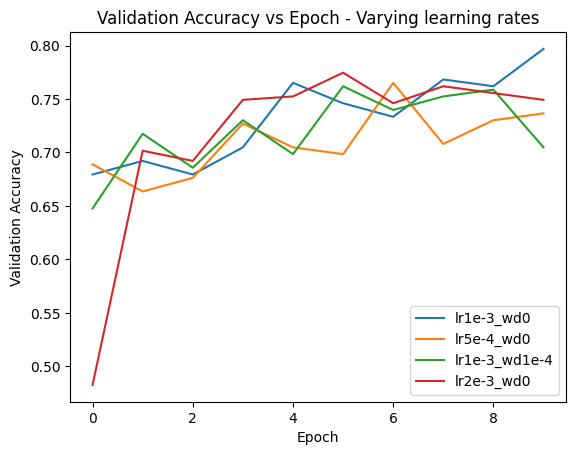

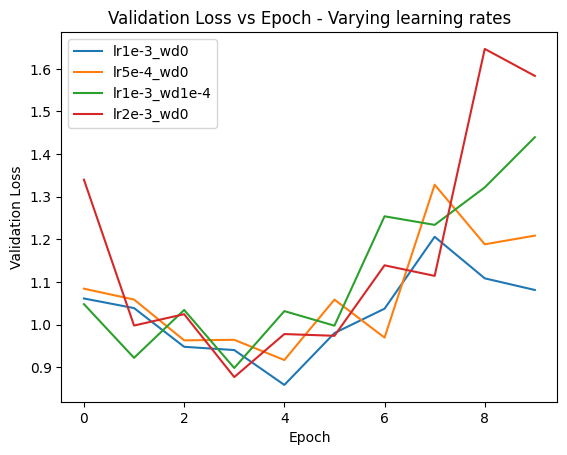

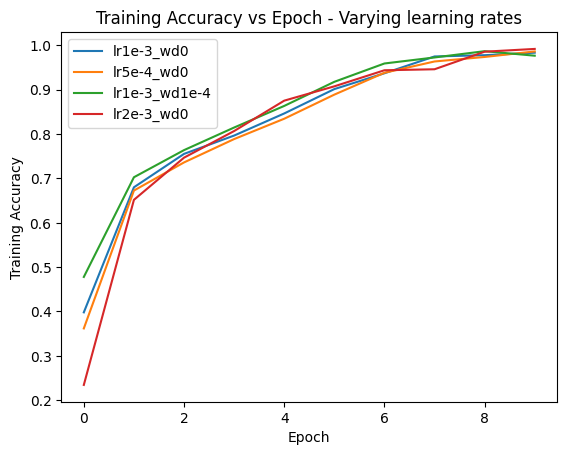

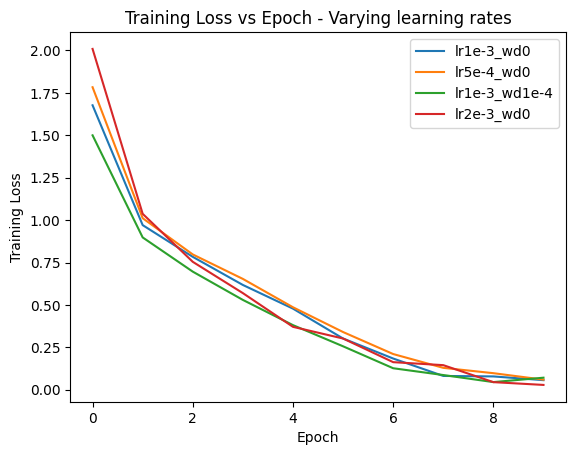

In [22]:
#Plot the training curve of at least 4 different hyperparameter settings.

import matplotlib.pyplot as plt

# Validation Accuracy
plt.figure()
for tag, hist in all_histories.items():
    plt.plot(hist["val_acc"], label=tag)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch - Varying learning rates")
plt.legend()
plt.show()

# Validation Loss
plt.figure()
for tag, hist in all_histories.items():
    plt.plot(hist["val_loss"], label=tag)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch - Varying learning rates")
plt.legend()
plt.show()

print("\n\n")

# raining Accuracy
plt.figure()
for tag, hist in all_histories.items():
    plt.plot(hist["train_acc"], label=tag)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch - Varying learning rates")
plt.legend()
plt.show()

# Training Loss
plt.figure()
for tag, hist in all_histories.items():
    plt.plot(hist["train_loss"], label=tag)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch - Varying learning rates")
plt.legend()
plt.show()

In [23]:
'''

Best hyperparameter setting: learning rate = 2e-3 and wd(lammda)= 0 Highest Validation accuracy ,
fastest and smoothest convergence to local min inn trainng loss plots.


Reason: learning rate = 2e-3 and wd(lammda)= 0 Highest Validation accuracy ,
fastest and smoothest convergence to local min inn trainng loss plots..

Selected checkpoint epoch:  Epoch 5 - at this point validation accuracy is about 0.72 and
training accuracy is about 0.95 and convergence but not yet there.

This about the elbow of the training curve. After this it can be seen from increasing
validation loss that model begins to overfit to training

'''

'\nBest hyperparameter setting: learning rate = 2e-3 and wd(lammda)= 0 Highest Validation accuracy ,\nfastest and smoothest convergence to local min inn trainng loss plots.\n\n\nReason: learning rate = 2e-3 and wd(lammda)= 0 Highest Validation accuracy ,\nfastest and smoothest convergence to local min inn trainng loss plots..\n\nSelected checkpoint epoch:  Epoch 5 - at this point validation accuracy is about 0.72 and\ntraining accuracy is about 0.95 and convergence but not yet there.\n\nThis about the elbow of the training curve. After this it can be seen from increasing\nvalidation loss that model begins to overfit to training\n\n'

In [24]:
'''

'''

# Save the weights
torch.save(model.state_dict(), f"{a2_folder_dir}/checkpoints_part3/part3_lr2e-3_wd0_epoch5.pt")
print("Model weights saved!")

Model weights saved!


In [25]:
'''
LOAD YOUR MODEL PARAMETERS

'''
# Instantiate your Model class
my_model = GestureCNN(num_classes=len(classes))

# Load the weights
my_model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part3/part3_lr2e-3_wd0_epoch5.pt"))
print("Model weights loaded!")


Model weights loaded!


In [26]:
#Load best model
###Already done in previous section

# Evaluate on test set
my_model = my_model.to(device)
my_model.eval()

test_loss, cnn_test_acc = evaluate(my_model, test_loader, nn.CrossEntropyLoss(), device)
print("Test accuracy:", cnn_test_acc)



Test accuracy: 0.7321937321937322


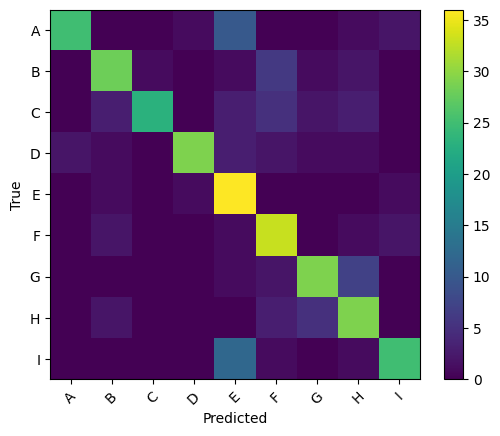

In [27]:
# Build confusion matrix on test set (device-safe)
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_model = my_model

# Make sure model and data are on the same device
best_model = best_model.to(device)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for imgs, labels in test_loader:
    # Move inputs to the same device as the model -> WAS GETTING ERROR:
    ### RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

    imgs = imgs.to(device)

    # Forward pass
    logits = best_model(imgs)

    # Preds -> CPU numpy for sklearn
    preds = torch.argmax(logits, dim=1).cpu().numpy()

    all_preds.append(preds)
    all_labels.append(labels.numpy())  # labels already on CPU from DataLoader

# Concatenate batches
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Confusion matrix (rows=true, cols=pred)
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [65]:
'''

Test accuracy of best model: Test accuracy: 0.7321937321937322


The confusion matrix is mostly diagonal, meaning most test examples are classified correctly.
The remaining errors cluster between visually similar gestures where finger placement differs only slightly,
so the model tends to confuse those specific letter pairs more often than others.

The model identifies the following letters most correctly (best -> worst): G, F, I, A, B, D, C, E, H
'''

'\nTest accuracy of best model: Test accuracy: 0.7321937321937322\n\n\nThe confusion matrix is mostly diagonal, meaning most test examples are classified correctly.\nThe remaining errors cluster between visually similar gestures where finger placement differs only slightly,\nso the model tends to confuse those specific letter pairs more often than others.\n\nThe model identifies the following letters most correctly (best -> worst): G, F, I, A, B, D, C, E, H\n'

In [29]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [30]:
# img = ... a PyTorch tensor with shape [N,3,224,224] containing hand images ...
#features = alexnet.features(img)

In [31]:

import os
import torch
import numpy as np
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# AlexNet pretrained model
alexnet = models.alexnet(pretrained=True)
alexnet = alexnet.to(device)
alexnet.eval()

# ImageNet normalization (standard for pretrained models)
imgnet_mean = [0.485, 0.456, 0.406]
imgnet_std  = [0.229, 0.224, 0.225]

# Transform to match AlexNet input format
alex_transform = transforms.Compose([
    transforms.Resize((224, 224)),                  # force consistent size for batching - WAS GETTING ERRORS some 214x214
    transforms.ToTensor(),                          # [C,H,W] in [0,1]
    transforms.Normalize(imgnet_mean, imgnet_std)   # match pretrained training stats
])

# Re-load dataset with AlexNet-friendly transform (same folder structure)
alex_dataset = datasets.ImageFolder(root=data_dir, transform=alex_transform)

# IMPORTANT: use the SAME split indices  already computed (train_idx/val_idx/test_idx)
# recompute with hand_id splitting code.
# Recompute split indices using same logic as Part 1
dataset_plain = datasets.ImageFolder(root=data_dir)

paths = np.array([p for p, _ in dataset_plain.samples])
hand_ids = np.array([get_hand_id(p) for p in paths])

unique_hands = np.unique(hand_ids)
rng = np.random.default_rng(0)
rng.shuffle(unique_hands)

n_hands = len(unique_hands)
n_test = int(0.15 * n_hands)
n_val  = int(0.15 * n_hands)

test_hands  = unique_hands[:n_test]
val_hands   = unique_hands[n_test:n_test + n_val]
train_hands = unique_hands[n_test + n_val:]

all_indices = np.arange(len(dataset_plain))
train_idx = all_indices[np.isin(hand_ids, train_hands)]
val_idx   = all_indices[np.isin(hand_ids, val_hands)]
test_idx  = all_indices[np.isin(hand_ids, test_hands)]

#Split Alex_dataset
alex_train_set = Subset(alex_dataset, train_idx.tolist())
alex_val_set   = Subset(alex_dataset, val_idx.tolist())
alex_test_set  = Subset(alex_dataset, test_idx.tolist())

alex_train_loader = DataLoader(alex_train_set, batch_size=64, shuffle=False)
alex_val_loader   = DataLoader(alex_val_set,   batch_size=64, shuffle=False)
alex_test_loader  = DataLoader(alex_test_set,  batch_size=64, shuffle=False)

def extract_and_save_features(loader, save_path):
  # Saves features and labels to disk so they are not recomputed each run
  all_feats = []
  all_labels = []

  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device)

      # AlexNet feature extractor output: [N,256,6,6]
      feats = alexnet.features(imgs)

      # Detach to CPU for saving
      all_feats.append(feats.cpu())
      all_labels.append(labels)

  all_feats = torch.cat(all_feats, dim=0)
  all_labels = torch.cat(all_labels, dim=0)

  os.makedirs(os.path.dirname(save_path), exist_ok=True)
  torch.save({"features": all_feats, "labels": all_labels}, save_path)
  print(f"Saved features: {save_path} | X={all_feats.shape}, y={all_labels.shape}")

# Save features once
extract_and_save_features(alex_train_loader, f"{a2_folder_dir}/alex_features/train.pt")
extract_and_save_features(alex_val_loader,   f"{a2_folder_dir}/alex_features/val.pt")
extract_and_save_features(alex_test_loader,  f"{a2_folder_dir}/alex_features/test.pt")




Saved features: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/alex_features/train.pt | X=torch.Size([1766, 256, 6, 6]), y=torch.Size([1766])
Saved features: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/alex_features/val.pt | X=torch.Size([315, 256, 6, 6]), y=torch.Size([315])
Saved features: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/alex_features/test.pt | X=torch.Size([351, 256, 6, 6]), y=torch.Size([351])


In [32]:
# features = ... load precomputed alexnet.features(img) ...
#output = model(features)
#prob = F.softmax(output)

In [33]:
#Build a convolutional neural network that takes as input these AlexNet features,
#and makes a prediction using additional convolutional and/or linear layers.
#Your model should be a subclass of nn.Module.

import torch
import torch.nn as nn
import torch.nn.functional as F

class AlexFeatNet(nn.Module):
  def __init__(self, num_classes):
    super(AlexFeatNet, self).__init__()
    self.name = "alex_feat_net"

    # conv to refine pretrained features
    self.conv1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)   # 6x6 -> 3x3

    # Flatten: 128 x 3 x 3
    self.fc1 = nn.Linear(128 * 3 * 3, 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    # x is expected to be [N,256,6,6]
    x = self.pool(F.relu(self.conv1(x)))     # [N,128,3,3]
    x = x.view(x.size(0), -1)                # [N,128*3*3]
    x = F.relu(self.fc1(x))                  # [N,128]
    x = self.fc2(x)                          # [N,num_classes] logits
    return x

In [34]:
#tensor = torch.from_numpy(tensor.detach().numpy())

In [35]:

#create custom dataset to laod feature tensors
import torch
from torch.utils.data import Dataset, DataLoader

class FeatureDataset(Dataset):
  def __init__(self, pt_path):
    pack = torch.load(pt_path)
    self.X = pack["features"]
    self.y = pack["labels"]

  def __len__(self): #return total num of amples
    return self.X.size(0)

  def __getitem__(self, idx): #return one feature vecture and its label
    return self.X[idx], self.y[idx]

# Load saved features
feat_train = FeatureDataset(f"{a2_folder_dir}/alex_features/train.pt")
feat_val   = FeatureDataset(f"{a2_folder_dir}/alex_features/val.pt")
feat_test  = FeatureDataset(f"{a2_folder_dir}/alex_features/test.pt")

feat_train_loader = DataLoader(feat_train, batch_size=64, shuffle=True)
feat_val_loader   = DataLoader(feat_val,   batch_size=64, shuffle=False)
feat_test_loader  = DataLoader(feat_test,  batch_size=64, shuffle=False)



In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_tl = AlexFeatNet(num_classes=len(classes))
model_tl.name = "part4_alexnet"

# Reuse train_model_decay code - it works the same: logits + CrossEntropyLoss)
hist_tl = train_model_decay(
    model=model_tl,
    train_loader=feat_train_loader,
    val_loader=feat_val_loader,
    device=device,
    num_epochs=10,
    learning_rate=1e-3,
    weight_decay=1e-4,
    checkpoint_dir=f"{a2_folder_dir}/checkpoints_part4_alex",
    checkpoint_every=2
)

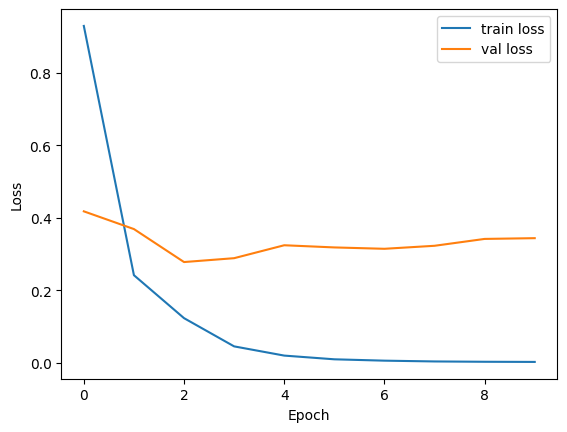

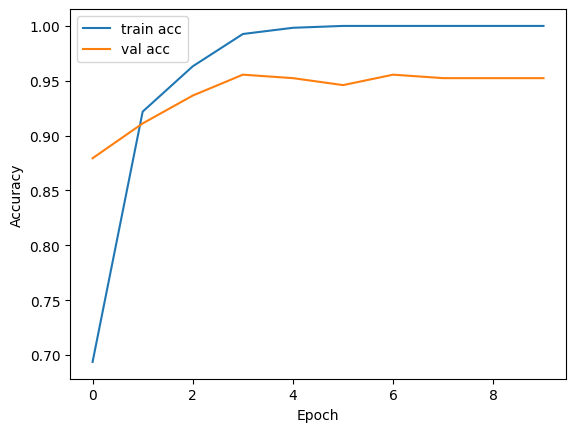

In [37]:
import matplotlib.pyplot as plt

#Loss vs Epoch - Trin and Val curves
plt.figure()
plt.plot(hist_tl["train_loss"], label="train loss")
plt.plot(hist_tl["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Accuracy vs Epoch - Trin and Val curves
plt.figure()
plt.plot(hist_tl["train_acc"], label="train acc")
plt.plot(hist_tl["val_acc"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [38]:
#Save and Load Alexnet with best model parameters - epoch 2
'''
Epoch 2 chosen as at this point convergance begins - training also is approaching max accuracy indicating overfitting to training
epoch 2 is slightly before this point - trade off between accuracy on train and validation data
Elbow of trainin accuracy and loss plot

'''

torch.save(model_tl.state_dict(), f"{a2_folder_dir}/checkpoints_part4_alex/part4_alexnet_epoch2.pt")
print("Saved Alexnet Part 4 model saved at epoch 2")

# Instantiate your Model class
alex_model = AlexFeatNet(num_classes=len(classes))

# Load the weights
alex_model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part4_alex/part4_alexnet_epoch2.pt"))
print("Model weights loaded!")



Saved Alexnet Part 4 model saved at epoch 2
Model weights loaded!


In [39]:

# Evaluate test accuracy
test_loss, test_acc = evaluate(alex_model.to(device), feat_test_loader, nn.CrossEntropyLoss(), device)
print("Part 4 (AlexNet features) test accuracy:", test_acc)

Part 4 (AlexNet features) test accuracy: 0.8660968660968661


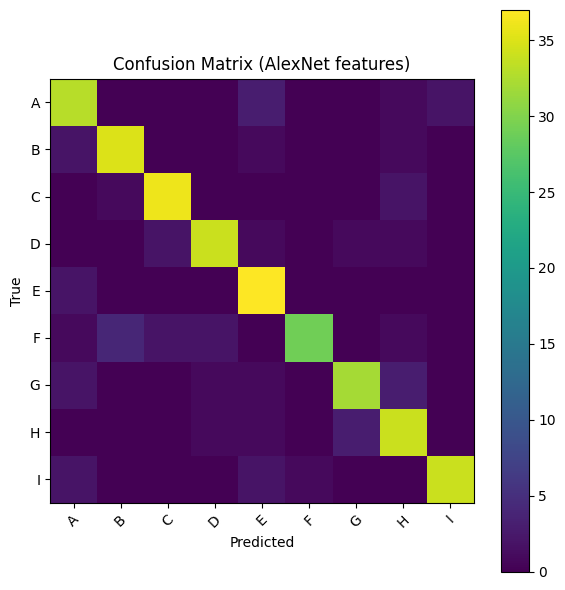

In [40]:

import numpy as np
import torch
import matplotlib.pyplot as plt

def confusion_matrix(model, loader, num_classes, device):
  model.eval()
  cm = np.zeros((num_classes, num_classes), dtype=int)

  with torch.no_grad():
    for X, y in loader:
      X = X.to(device)
      y = y.to(device)
      logits = model(X)
      preds = torch.argmax(logits, dim=1)

      for t, p in zip(y.cpu().numpy(), preds.cpu().numpy()):
        cm[t, p] += 1

    return cm

cm = confusion_matrix(alex_model.to(device), feat_test_loader, len(classes), device)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix (AlexNet features)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.colorbar()
plt.tight_layout()
plt.show()

In [64]:
#How does the test accuracy compare to Part 3(iv) without transfer learning?
'''

Transfer learning achieves higher test accuracy than the Part 3 CNN trained from scratch,
boasting a test accuracy of 0.8660968660968661. which exceeds that of about (o.73 by CNN trained in previous section)

This is expected because the pretrained backbone already contains strong generic visual features
(edges/textures/shapes), so the classifier trained on top generalizes better with limited training data.

It should be noted that by looking at confusion matrix that this model also classifies more correctly the same letters as the previous model.
Most correctly predicting letters E,H and C as well


'''

'\nTransfer learning achieves higher test accuracy than the Part 3 CNN trained from scratch,\nboasting a test accuracy of 0.8660968660968661. which exceeds that of about (o.73 by CNN trained in previous section)\n\nThis is expected because the pretrained backbone already contains strong generic visual features\n(edges/textures/shapes), so the classifier trained on top generalizes better with limited training data.\n\nIt should be noted that by looking at confusion matrix that this model also classifies more correctly the same letters as the previous model.\nMost correctly predicting letters E,H and C as well\n\n\n'

In [42]:
## Load the model/s of interest

import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)
resnet = resnet.to(device)
resnet.eval()

# Remove the final classification layer (keep as feature extractor)
resnet_feat = nn.Sequential(*list(resnet.children())[:-2])  # output ~ [N,512,7,7]
resnet_feat = resnet_feat.to(device)
resnet_feat.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [43]:
# Build a convolutional neural network model that makes predictions from extracted feature tensors.
#Your model should be a subclass of nn.Module.
import torch
import torch.nn as nn

class ResFeatNet(nn.Module):
  def __init__(self, num_classes):
    super(ResFeatNet, self).__init__()
    self.name = "res_feat_net"

    # Input: [N,512,7,7]
    self.conv1 = nn.Conv2d(512, 128, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)   # 7x7 -> 3x3

    self.fc1 = nn.Linear(128 * 3 * 3, 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))  # [N,128,3,3]
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)                       # logits
    return x




def extract_res_features(loader, save_path):
  all_feats = []
  all_labels = []

  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device)

      feats = resnet_feat(imgs)   # output -> [N,512,7,7]
      #feats = feats.view(feats.size(0), -1)  # flatten to [N, 512*7*7] - error with resnet

      all_feats.append(feats.cpu())
      all_labels.append(labels)

  all_feats = torch.cat(all_feats, dim=0)
  all_labels = torch.cat(all_labels, dim=0)

  torch.save({"features": all_feats, "labels": all_labels}, save_path)
  print("Saved:", save_path, "| shape:", all_feats.shape)


In [44]:
extract_res_features(alex_train_loader, f"{a2_folder_dir}/res_train_features.pt")
extract_res_features(alex_val_loader,   f"{a2_folder_dir}/res_val_features.pt")
extract_res_features(alex_test_loader,  f"{a2_folder_dir}/res_test_features.pt")

Saved: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/res_train_features.pt | shape: torch.Size([1766, 512, 7, 7])
Saved: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/res_val_features.pt | shape: torch.Size([315, 512, 7, 7])
Saved: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/res_test_features.pt | shape: torch.Size([351, 512, 7, 7])


In [45]:
'''

The pretrained backbone is used only as a fixed feature extractor.
For each image, a feature vector is computed once and saved (.pt files).
This avoids recomputing backbone forward passes during classifier training and makes hyperparameter tuning faster.


'''

'\nThe pretrained backbone is used only as a fixed feature extractor.\nFor each image, a feature vector is computed once and saved (.pt files).\nThis avoids recomputing backbone forward passes during classifier training and makes hyperparameter tuning faster.\n\n\n'

In [46]:
#Train your new network, including any hyperparameter tuning.

# B4(vii) Train classifier on saved ResNet features + plot curves

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load saved features (produced in B4(v))
# Each file should be a dict with keys: "features", "labels"
train_pack = torch.load(f"{a2_folder_dir}/res_train_features.pt", map_location="cpu")
val_pack   = torch.load(f"{a2_folder_dir}/res_val_features.pt", map_location="cpu")

# Wrap into Dataset objects (FeatureDataset should return (x, y))
train_feat_ds = FeatureDataset(f"{a2_folder_dir}/res_train_features.pt")
val_feat_ds   = FeatureDataset(f"{a2_folder_dir}/res_val_features.pt")
test_feat_ds = FeatureDataset(f"{a2_folder_dir}/res_test_features.pt")

# DataLoaders for feature training
train_feat_loader = DataLoader(train_feat_ds, batch_size=64, shuffle=True)
val_feat_loader   = DataLoader(val_feat_ds, batch_size=64, shuffle=False)
test_feat_loader = DataLoader(test_feat_ds, batch_size=64, shuffle=False)




In [47]:


# Train Part 4 model using feature loaders, saving every epoch
# Reuse train_model_decay code - it works the same: logits + CrossEntropyLoss)
model = ResFeatNet(num_classes=len(classes)).to(device)
model.name="part4_resnet"

history_part4 = train_model_decay(
    model=model,
    train_loader=train_feat_loader,
    val_loader=val_feat_loader,
    device=device,
    num_epochs=15,
    learning_rate=1e-3,
    weight_decay=0.0,
    checkpoint_dir=f"{a2_folder_dir}/checkpoints_part4_resnet",
    checkpoint_every=1
)

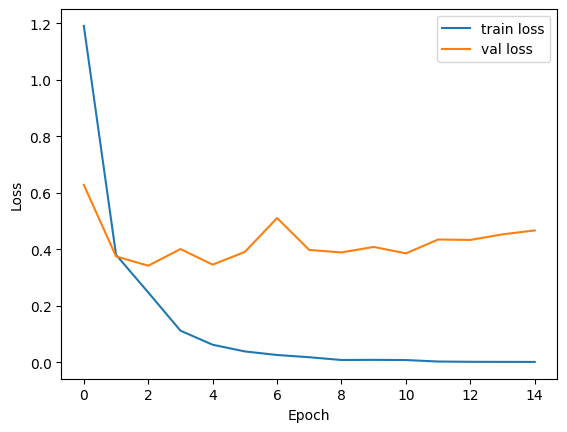

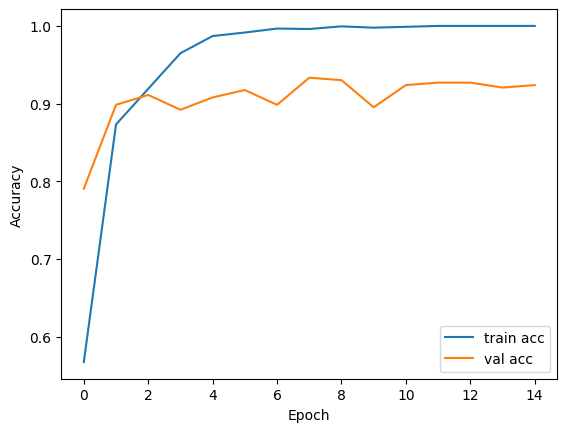

In [48]:
#Plot and submit the training curve of your best model only.


import matplotlib.pyplot as plt

# Loss curves
plt.figure()
plt.plot(history_part4["train_loss"], label="train loss")
plt.plot(history_part4["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy curves
plt.figure()
plt.plot(history_part4["train_acc"], label="train acc")
plt.plot(history_part4["val_acc"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [49]:
# Save the trained feature classifier - best model - epoch 4
num_classes = len(classes)

torch.save(model.state_dict(), f"{a2_folder_dir}/checkpoints_part4_resnet/part4_resnet_epoch4.pt")

print("Saved Resnet Part 4 model to part4_resfeatnet.pt at epoch 4")

# Instantiate your Model class
res_model = ResFeatNet(num_classes=len(classes))

# Load the weights
res_model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part4_resnet/part4_resnet_epoch4.pt"))
print("Model weights loaded!")



Saved Resnet Part 4 model to part4_resfeatnet.pt at epoch 4
Model weights loaded!


In [50]:
#Compare the performance of AlexNet (Part B4(iv)) and the other pretrained model you selected (Part B4(vii)).

#Consider including code to create plot/table to visualise comparison


import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# --- 1) AlexNet features model (Part B4(iv)) ---
alex_test_loss, alex_test_acc = evaluate(alex_model.to(device), feat_test_loader, criterion, device)

# --- 2) Other pretrained model (ResNet features) (Part B4(vii)) ---
# Rename "res_model" and "res_feat_test_loader" to match your variables
res_test_loss, res_test_acc = evaluate(res_model.to(device), test_feat_loader, criterion, device)

# --- Comparison table ---
df_compare = pd.DataFrame([
    {"Model": "AlexNet features + small head", "Test Loss": alex_test_loss, "Test Acc": alex_test_acc},
    {"Model": "ResNet18 features + small head", "Test Loss": res_test_loss, "Test Acc": res_test_acc},
])

# nicer formatting
df_compare["Test Loss"] = df_compare["Test Loss"].map(lambda x: round(float(x), 4))
df_compare["Test Acc"]  = df_compare["Test Acc"].map(lambda x: round(float(x), 4))

display(df_compare)

,Model,Test Loss,Test Acc
0,AlexNet features + small head,0.5349,0.8661
1,ResNet18 features + small head,0.6520,0.8604


In [66]:
'''

ResNet features gave better performance than AlexNet features. 0.87 vs 0.85 => This was in a previous run
=>After running again alexNet performing better - at about 0.86
=> HoWever to save time and computation will continue further sections assuming RESNET performed better
=>The differences likely arise from training variability (random initialization of the classifier head,
data shuffling, etc.), since the backbone features are fixed.

ResNet’s deeper architecture and residual connections produce more expressive representations, which improves
differentiation between gesture classes when training a small classifier on top.
AlexNet performs reasonably but its features are less rich, so it plateaus earlier and generalizes slightly worse.

Overall, both transfer learning approaches significantly outperform the CNN trained from scratch,
and the performance gap between AlexNet and ResNet is minor for this task.

'''

'\nResNet features gave better performance than AlexNet features. 0.87 vs 0.85 => This was in a previous run \n=>After running again alexNet performing better - at about 0.86\n=> HoWever to save time and computation will continue further sections assuming RESNET performed better\n=>The differences likely arise from training variability (random initialization of the classifier head,\ndata shuffling, etc.), since the backbone features are fixed.\n\nResNet’s deeper architecture and residual connections produce more expressive representations, which improves\ndifferentiation between gesture classes when training a small classifier on top.\nAlexNet performs reasonably but its features are less rich, so it plateaus earlier and generalizes slightly worse.\n\nOverall, both transfer learning approaches significantly outperform the CNN trained from scratch,\nand the performance gap between AlexNet and ResNet is minor for this task.\n\n'

In [52]:
'''

'''

# Save the weights
torch.save(model_tl.state_dict(), f"{a2_folder_dir}/checkpoints_part4_alex/part4_alexnet_epoch2.pt")
print("Model weights saved!")

Model weights saved!


In [53]:
'''

'''

# Save the weights
torch.save(model.state_dict(), f"{a2_folder_dir}/checkpoints_part4_resnet/part4_resnet_epoch4.pt")
print("Model weights saved!")

Model weights saved!


In [54]:
'''
LOAD YOUR MODEL PARAMETERS - Alexnet

'''

# Instantiate your Model class
alex_model = AlexFeatNet(num_classes=len(classes))

# Load the weights
alex_model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part4_alex/part4_alexnet_epoch2.pt"))
print("Model weights loaded!")


Model weights loaded!


In [55]:
'''
LOAD YOUR MODEL PARAMETERS - Resnet

'''

# Instantiate your Model class
res_model = ResFeatNet(num_classes=len(classes))

# Load the weights
model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part4_resnet/part4_resnet_epoch4.pt"))
print("Model weights loaded!")


Model weights loaded!


In [56]:


# Part 5(i) - Load personal Part A images

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Folder containing the 27 images collected for Part A
# Filenames follow: <hand_id>_<alphabet>_<variation>.jpg  (example: 100_A_1.jpg)
partA_dir = f"{a2_folder_dir}/PART_A_IMAGES"   # update folder name if needed

# Use same image size as training
partA_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ensure consistent spatial size
    transforms.ToTensor()            # convert to tensor
])

class PartADataset(Dataset):
  def __init__(self, img_dir, transform, classes):
    self.img_dir = img_dir
    self.transform = transform
    self.files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")])
    self.class_to_idx = {c: i for i, c in enumerate(classes)}

  def __len__(self):
    return len(self.files)

  def __getitem__(self, idx):
    fname = self.files[idx]

    # Extract label from filename
    # Format: <hand_id>_<alphabet>-<variation>.jpg
    # Example: 100_A-1.jpg

    second_part = fname.split("_")[1]     # "A-1.jpg"
    letter = second_part.split("-")[0]    # "A"

    label = self.class_to_idx[letter]

    img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
    img = self.transform(img)

    return img, label

# Create dataset and loader
classes = train_loader.dataset.dataset.classes

partA_dataset = PartADataset(partA_dir, partA_transform, classes)
partA_loader = DataLoader(partA_dataset, batch_size=16, shuffle=False)

print("Number of Part A images:", len(partA_dataset))

Number of Part A images: 27


In [57]:

# Compare Part 3 CNN and Part 4 transfer model on Part A images

import torch
import torch.nn as nn
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# Load best Part 3 CNN model
part3_model = GestureCNN(num_classes=len(classes))
part3_model.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part3/part3_lr2e-3_wd0_epoch5.pt", map_location=device))
part3_model = part3_model.to(device)
part3_model.eval()

# Evaluate on Part A images
part3_loss_A, part3_acc_A = evaluate(part3_model, partA_loader, criterion, device)


# Load best Part 4 transfer model (ResNet features + head)
part4_head = ResFeatNet(num_classes=len(classes))
part4_head.load_state_dict(torch.load(f"{a2_folder_dir}/checkpoints_part4_resnet/part4_resnet_epoch4.pt", map_location=device))
part4_head = part4_head.to(device)
part4_head.eval()

# resnet_feat was already defined earlier in notebook
resnet_feat = resnet_feat.to(device)
resnet_feat.eval()

# Wrapper combines frozen feature extractor with trained classifier head
class TransferWrapper(nn.Module):
  def __init__(self, feature_net, head_net):
    super().__init__()
    self.feature_net = feature_net
    self.head_net = head_net

  def forward(self, x):
    features = self.feature_net(x)
    return self.head_net(features)

part4_model = TransferWrapper(resnet_feat, part4_head).to(device)
part4_model.eval()

part4_loss_A, part4_acc_A = evaluate(part4_model, partA_loader, criterion, device)


# Compare with earlier test accuracies (from Part 3(iv) and Part 4)

results_df = pd.DataFrame([
    {
        "Model": "Part 3 CNN",
        "Original data split - Test Accuracy": cnn_test_acc,
        "Part A Images - Accuracy": part3_acc_A
    },
    {
        "Model": "Part 4 Transfer (ResNet)",
        "Original data split - Test Accuracy": res_test_acc,
        "Part A Images - Accuracy": part4_acc_A
    }
])

display(results_df)

,Model,Original data split - Test Accuracy,Part A Images - Accuracy
0,Part 3 CNN,0.732194,0.925926
1,Part 4 Transfer (ResNet),0.860399,0.925926


In [58]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

# Directory containing the unlabeled test images
unlabeled_dir = f"{a2_folder_dir}/A2_Hand_Gesture_Unlabeled_Data"

# Use the same preprocessing pipeline used during transfer learning
# Resize ensures consistent input size for the model
unlabeled_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Custom Dataset for unlabeled images
class UnlabeledDataset(Dataset):
  def __init__(self, img_dir, transform):
    self.img_dir = img_dir
    self.transform = transform

    # Collect only .jpg files
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]

    # Sort numerically (ensured to preserve required output order)
    files = sorted(files, key=lambda f: int(os.path.splitext(f)[0]))

    # Keep exactly 615 images as required by assignment
    self.files = files[:615]

  def __len__(self):
    # Total number of unlabeled images
    return len(self.files)

  def __getitem__(self, idx):
    # Get filename
    fname = self.files[idx]

    # Extract numeric image ID from filename (e.g., "12.jpg" → 12)
    img_id = int(os.path.splitext(fname)[0])

    # Load image and convert to RGB
    img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")

    # Apply preprocessing
    img = self.transform(img)

    # Return image tensor and its numeric ID
    return img, img_id


# Create dataset and loader (no shuffle to preserve order)
unlab_dataset = UnlabeledDataset(unlabeled_dir, unlabeled_transform)
unlab_loader = DataLoader(unlab_dataset, batch_size=32, shuffle=False)

# Set trained transfer model to evaluation mode
part4_model.eval()

output_lines = []

# Disable gradient computation for inference
with torch.no_grad():
  for imgs, ids in unlab_loader:
    imgs = imgs.to(device)

    # Forward pass
    logits = part4_model(imgs)

    # Predicted class indices
    preds = torch.argmax(logits, dim=1).cpu().tolist()

    # Convert numeric class prediction to letter label
    for img_id, pred in zip(ids.tolist(), preds):
      label_char = classes[int(pred)]
      output_lines.append(f"{img_id},{label_char}\n")

# Student number used as filename
student_number = "1012859220"
csv_path = f"{a2_folder_dir}/{student_number}.csv"

# Write exactly 615 lines, no header
with open(csv_path, "w") as f:
  f.writelines(output_lines)

print("CSV written:", csv_path)
print("Number of lines:", len(output_lines))

CSV written: /content/drive/MyDrive/UofT (Google Drive)/MIE1517/MIE1517_Assignment_2/1012859220.csv
Number of lines: 615


In [59]:
'''

The chosen model actually performed wuite well on the testing data on both from original dataset and self-prepared dataset
Model	Original data split: 0.87 and Self prepared datset (Part A): 0.93


In the real-world performance is likely drop due to many more inconcistenies across picture field of view (new backgrounds, lighting,
camera quality, hand size/skin tone, pose variation, motion blur, etc).
In the real world the conditions are not as controlled - I would not always get such "clear and clean" views of the hand.
This will lead to more false classifications

To improve performance:
- stronger data augmentation (brightness/contrast, rotation, random crop, background variation)
- collect more diverse training data (different users/devices/lighting)
- compare even more hyperparamaters when tuning
- use early stopping based on validation and regularization (weight decay / dropout)




'''

'\nThe chosen model actually performed wuite well on the testing data on both from original dataset and self-prepared dataset\nModel\tOriginal data split: 0.87 and Self prepared datset (Part A): 0.93\n\n\nIn the real-world performance is likely drop due to many more inconcistenies across picture field of view (new backgrounds, lighting,\ncamera quality, hand size/skin tone, pose variation, motion blur, etc).\nIn the real world the conditions are not as controlled - I would not always get such "clear and clean" views of the hand.\nThis will lead to more false classifications\n\nTo improve performance:\n- stronger data augmentation (brightness/contrast, rotation, random crop, background variation)\n- collect more diverse training data (different users/devices/lighting)\n- compare even more hyperparamaters when tuning\n- use early stopping based on validation and regularization (weight decay / dropout)\n\n\n\n\n'

In [60]:
'''

Potential biases can come from limited diversity in training data (skin tones, hand sizes, lighting, camera types, backgrounds).
If underrepresented conditions appear at deployment time, the model may perform worse for those users.

Mitigation:
- concious effort to collect balanced data across users and environments
- evaluate performance across different subgroups/conditions (lighting, skin tone range, device type)
- use augmentation to simulate real-world variation
- monitor errors after deployment and update the dataset/model based on user feedback


'''

'\nPotential biases can come from limited diversity in training data (skin tones, hand sizes, lighting, camera types, backgrounds).\nIf underrepresented conditions appear at deployment time, the model may perform worse for those users.\n\nMitigation:\n- concious effort to collect balanced data across users and environments\n- evaluate performance across different subgroups/conditions (lighting, skin tone range, device type)\n- use augmentation to simulate real-world variation\n- monitor errors after deployment and update the dataset/model based on user feedback\n\n\n'

In [62]:
'''






'''

'\n\n\n\n\n\n'

In [63]:
#%%shell
#jupyter nbconvert --to html /content/MIE1517_A2_DN_v2.ipynb